In [38]:
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.metrics import (
    BinaryAccuracy,
    Precision,
    Recall,
    AUC
)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import json


In [2]:
def load_train(dataframe):

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        horizontal_flip=True,
        rotation_range=10
    )

    train_data = train_datagen.flow_from_dataframe(
        dataframe=dataframe,
        x_col='image_path',
        y_col='label',
        target_size=(224, 224),
        batch_size=32,
        class_mode='binary',
        shuffle=True,
        seed=42
    )

    return train_data

In [3]:
def load_validation(dataframe):

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    val_data = val_datagen.flow_from_dataframe(
        dataframe=dataframe,
        x_col='image_path',
        y_col='label',
        target_size=(224, 224),
        batch_size=32,
        class_mode='binary',
        shuffle=False
    )

    return val_data

In [4]:
def create_model():

    backbone = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    backbone.trainable = False

    model = Sequential([
        backbone,

        GlobalAveragePooling2D(),

        BatchNormalization(),

        Dense(256, activation='relu'),

        Dropout(0.4),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=[
            BinaryAccuracy(name='accuracy'),
            Precision(name='precision'),
            Recall(name='recall'),
            AUC(name='auc')
        ]
    )

    return model

In [5]:
def train_model(
    model,
    train_data,
    val_data,
    epochs=10
):

    callbacks = [

        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2
        ),

        ModelCheckpoint(
            "models/best_model.keras",
            save_best_only=True,
            monitor="val_loss"
        )
    ]

    print("Fase 1: Transfer Learning")

    history_1 = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=callbacks,
        verbose=2
    )

    print("Fase 2: Fine-Tuning")

    backbone = model.layers[0]

    backbone.trainable = True

    for layer in backbone.layers[:-30]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=[
            BinaryAccuracy(name="accuracy"),
            Precision(name="precision"),
            Recall(name="recall"),
            AUC(name="auc")
        ]
    )

    history_2 = model.fit(
        train_data,
        validation_data=val_data,
        epochs=5,
        callbacks=callbacks,
        verbose=2
    )

    return model, history_1, history_2

In [9]:
def load_test(dataframe):

    test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    test_data = test_datagen.flow_from_dataframe(
        dataframe=dataframe,
        x_col='image_path',
        y_col='label',
        target_size=(224,224),
        batch_size=32,
        class_mode='binary',
        shuffle=False
    )

    return test_data

In [7]:
df_train = pd.read_csv('../data/train.csv')
df_val = pd.read_csv('../data/val.csv')
df_test = pd.read_csv('../data/test.csv')

train_gen = load_train(df_train)
val_gen = load_validation(df_val)

model = create_model()

trained_model, history_1, history_2 = train_model(
    model,
    train_gen,
    val_gen
)

print("Entrenamiento finalizado.")

Found 3889 validated image filenames belonging to 2 classes.


Found 834 validated image filenames belonging to 2 classes.


       0/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   24576/16705208 ━━━━━━━━━━━━━━━━━━━━ 40s 2us/step

   57344/16705208 ━━━━━━━━━━━━━━━━━━━━ 31s 2us/step

...

Epoch 4/5


122/122 - 92s - 753ms/step - accuracy: 0.9787 - auc: 0.9946 - loss: 0.0700 - precision: 0.9703 - recall: 0.9877 - val_accuracy: 0.9808 - val_auc: 0.9940 - val_loss: 0.0642 - val_precision: 0.9654 - val_recall: 0.9976 - learning_rate: 1.0000e-05


Epoch 5/5


122/122 - 91s - 743ms/step - accuracy: 0.9792 - auc: 0.9954 - loss: 0.0636 - precision: 0.9689 - recall: 0.9903 - val_accuracy: 0.9808 - val_auc: 0.9942 - val_loss: 0.0624 - val_precision: 0.9654 - val_recall: 0.9976 - learning_rate: 1.0000e-05


Entrenamiento finalizado.


In [10]:
test_gen = load_test(df_test)

results = trained_model.evaluate(
    test_gen,
    return_dict=True
)

print(results)

Found 834 validated image filenames belonging to 2 classes.


C:\Users\pirom\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 1/27 ━━━━━━━━━━━━━━━━━━━━ 16s 645ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0019 - precision: 1.0000 - recall: 1.0000

 2/27 ━━━━━━━━━━━━━━━━━━━━ 12s 482ms/step - accuracy: 0.9844 - auc: 0.9995 - loss: 0.0312 - precision: 0.9730 - recall: 1.0000

 3/27 ━━━━━━━━━━━━━━━━━━━━ 13s 547ms/step - accuracy: 0.9826 - auc: 0.9995 - loss: 0.0346 - precision: 0.9689 - recall: 1.0000

...

24/27 ━━━━━━━━━━━━━━━━━━━━ 2s 692ms/step - accuracy: 0.9762 - auc: 0.9950 - loss: 0.0660 - precision: 0.9545 - recall: 1.0000

25/27 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step - accuracy: 0.9764 - auc: 0.9950 - loss: 0.0661 - precision: 0.9548 - recall: 1.0000

26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.9765 - auc: 0.9950 - loss: 0.0660 - precision: 0.9551 - recall: 1.0000

27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 666ms/step - accuracy: 0.9767 - auc: 0.9949 - loss: 0.0660 - precision: 0.9555 - recall: 1.0000


{'accuracy': 0.9796162843704224, 'auc': 0.9944648742675781, 'loss': 0.065482959151268, 'precision': 0.9609195590019226, 'recall': 1.0}


 1/27 ━━━━━━━━━━━━━━━━━━━━ 17s 670ms/step

 2/27 ━━━━━━━━━━━━━━━━━━━━ 12s 519ms/step

 3/27 ━━━━━━━━━━━━━━━━━━━━ 11s 493ms/step

 4/27 ━━━━━━━━━━━━━━━━━━━━ 11s 508ms/step

 5/27 ━━━━━━━━━━━━━━━━━━━━ 11s 509ms/step

...

23/27 ━━━━━━━━━━━━━━━━━━━━ 2s 510ms/step

24/27 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step

25/27 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step

26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step

27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 488ms/step


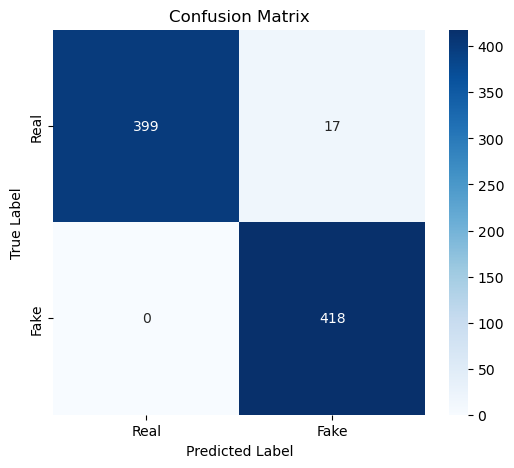

In [13]:
pred_probs = trained_model.predict(test_gen)

y_pred = (pred_probs > 0.5).astype(int).flatten()
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [15]:
plt.savefig(
    '../reports/confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

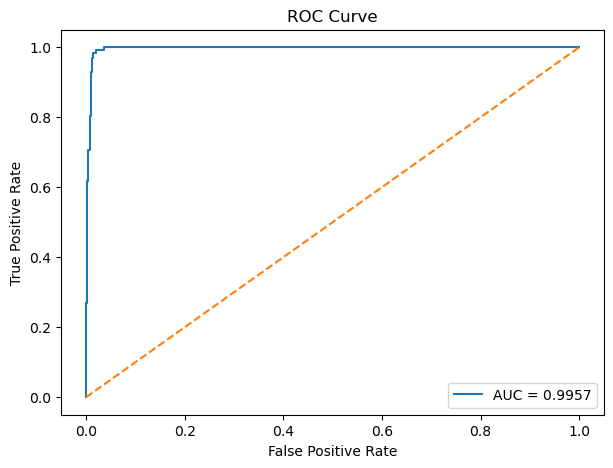

In [16]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(
    y_true,
    pred_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

In [17]:
plt.savefig(
    '../reports/roc_curve.png',
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

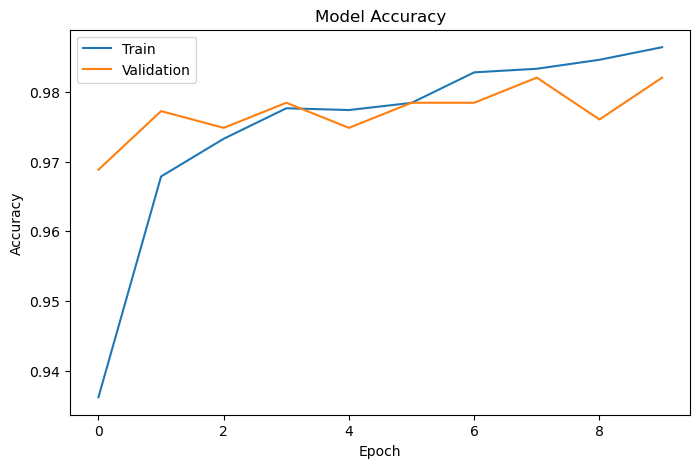

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    history_1.history['accuracy'],
    label='Train'
)

plt.plot(
    history_1.history['val_accuracy'],
    label='Validation'
)

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [21]:
plt.savefig(
    '../reports/Model_Accuracy.png',
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

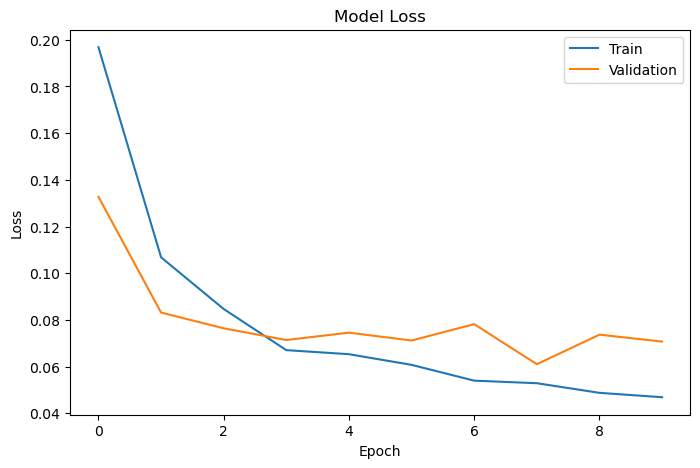

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    history_1.history['loss'],
    label='Train'
)

plt.plot(
    history_1.history['val_loss'],
    label='Validation'
)

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [23]:
plt.savefig(
    '../reports/Model_Loss.png',
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [24]:
pred_probs = trained_model.predict(test_gen)

y_pred = (pred_probs > 0.5).astype(int).flatten()

misclassified = np.where(
    y_pred != y_true
)[0]

 1/27 ━━━━━━━━━━━━━━━━━━━━ 17s 658ms/step

 2/27 ━━━━━━━━━━━━━━━━━━━━ 11s 478ms/step

 3/27 ━━━━━━━━━━━━━━━━━━━━ 10s 453ms/step

 4/27 ━━━━━━━━━━━━━━━━━━━━ 10s 464ms/step

 5/27 ━━━━━━━━━━━━━━━━━━━━ 10s 470ms/step

...

23/27 ━━━━━━━━━━━━━━━━━━━━ 1s 493ms/step

24/27 ━━━━━━━━━━━━━━━━━━━━ 1s 494ms/step

25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step

26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step

27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 475ms/step


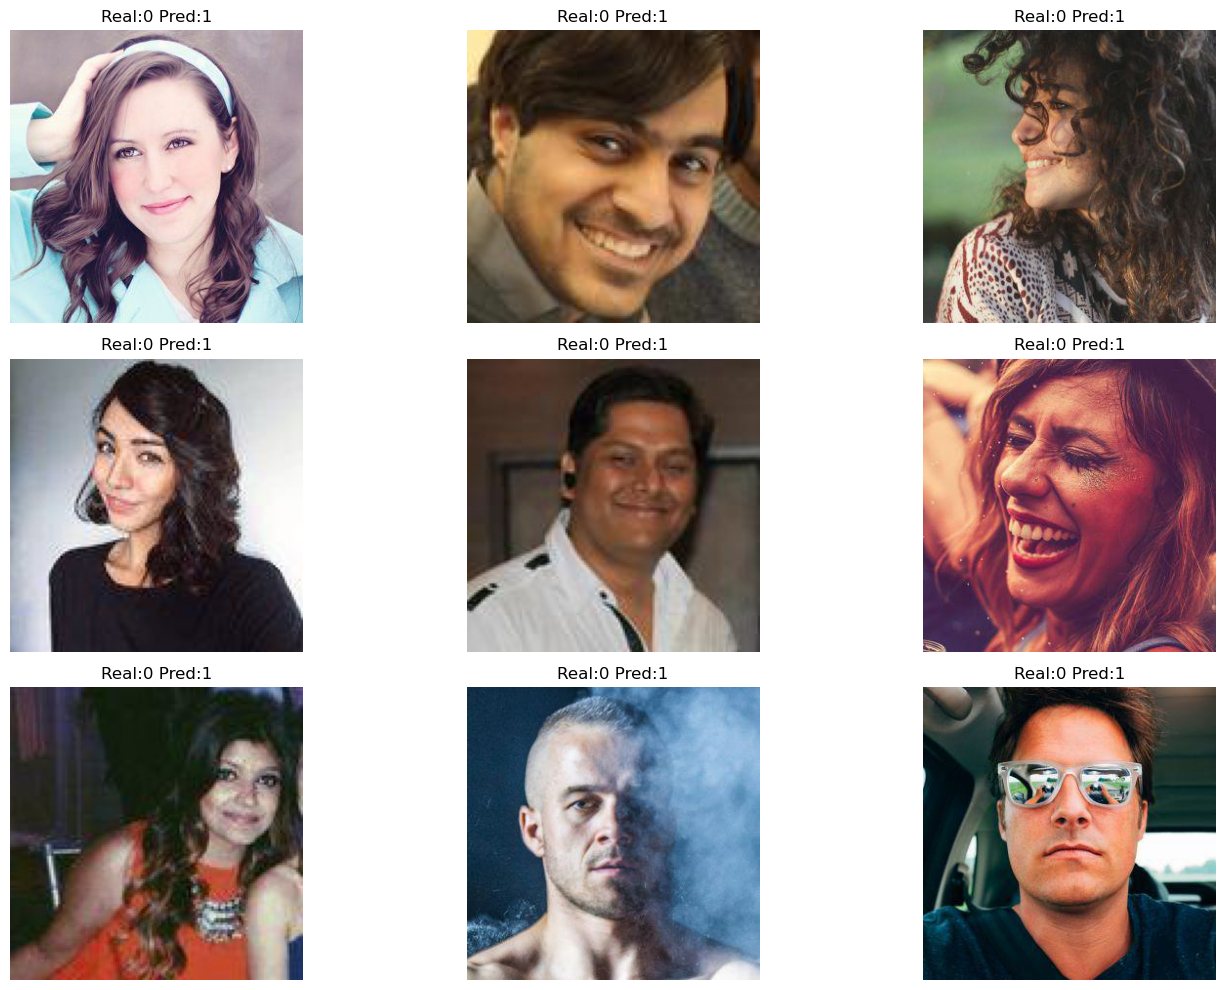

In [27]:
plt.figure(figsize=(15,10))

for i, idx in enumerate(misclassified[:9]):

    img_path = df_test.iloc[idx]['image_path']

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis('off')

    plt.title(
        f"Real:{y_true[idx]} Pred:{y_pred[idx]}"
    )

plt.tight_layout()
plt.show()

In [28]:
plt.savefig(
    '../reports/misclassified.png',
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [29]:
correct = np.where(
    y_pred == y_true
)[0]

print(f"Correctas: {len(correct)}")

Correctas: 817


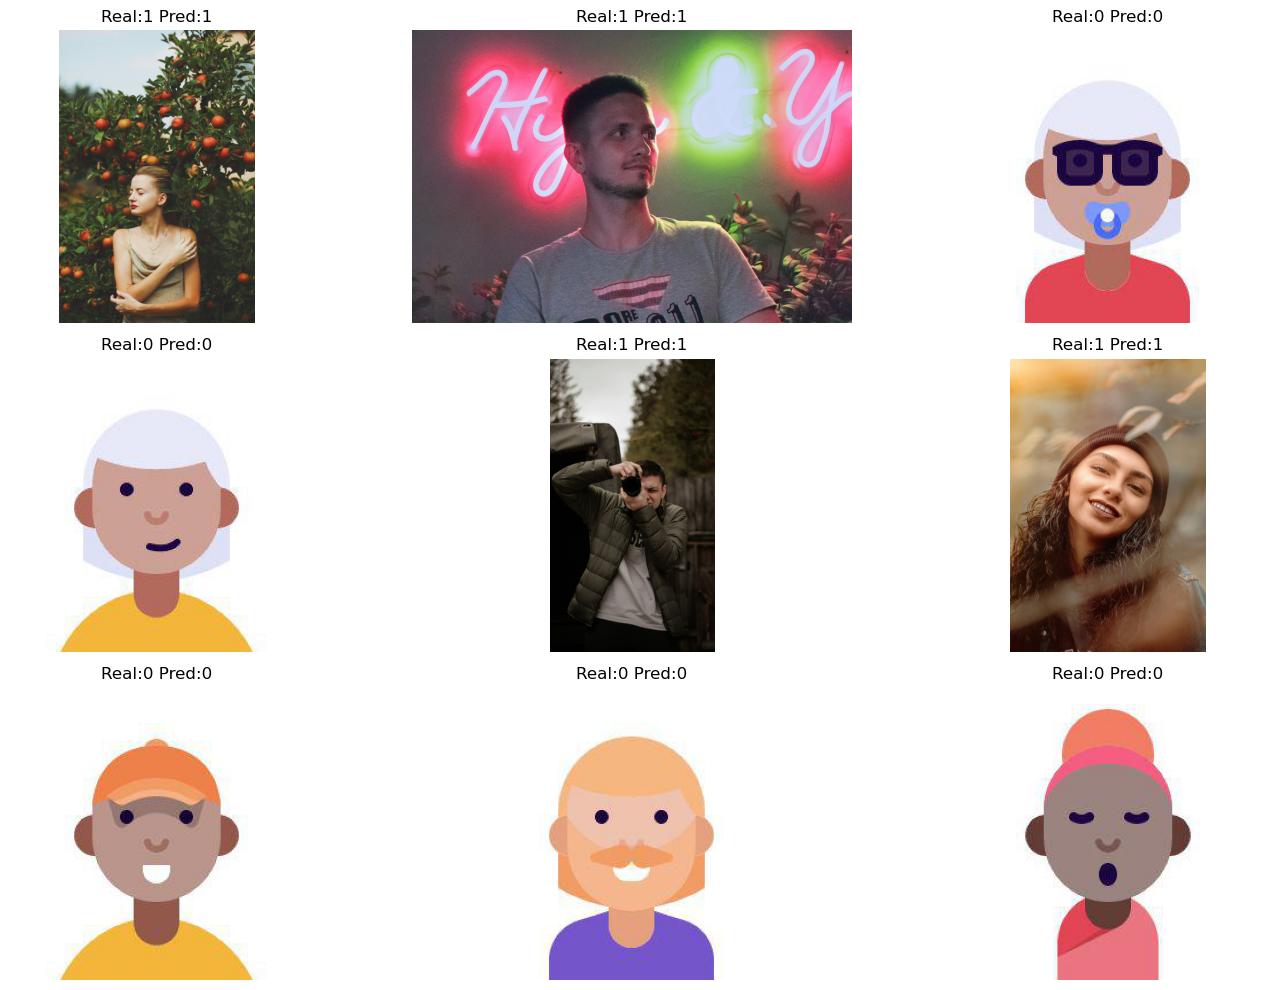

In [35]:
plt.figure(figsize=(15,10))

for i, idx in enumerate(correct[:9]):

    img_path = df_test.iloc[idx]['image_path']

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis('off')

    plt.title(
        f"Real:{y_true[idx]} Pred:{y_pred[idx]}"
    )

plt.tight_layout()
plt.show()

In [36]:
plt.savefig(
    '../reports/correct.png',
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [37]:
metrics = trained_model.evaluate(
    test_gen,
    return_dict=True
)

with open(
    '../reports/metrics.json',
    'w'
) as f:
    json.dump(metrics, f, indent=4)

 1/27 ━━━━━━━━━━━━━━━━━━━━ 16s 646ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0019 - precision: 1.0000 - recall: 1.0000

 2/27 ━━━━━━━━━━━━━━━━━━━━ 12s 499ms/step - accuracy: 0.9844 - auc: 0.9995 - loss: 0.0312 - precision: 0.9730 - recall: 1.0000

 3/27 ━━━━━━━━━━━━━━━━━━━━ 11s 491ms/step - accuracy: 0.9826 - auc: 0.9995 - loss: 0.0346 - precision: 0.9689 - recall: 1.0000

 4/27 ━━━━━━━━━━━━━━━━━━━━ 11s 508ms/step - accuracy: 0.9831 - auc: 0.9996 - loss: 0.0340 - precision: 0.9693 - recall: 1.0000

 5/27 ━━━━━━━━━━━━━━━━━━━━ 10s 499ms/step - accuracy: 0.9827 - auc: 0.9981 - loss: 0.0400 - precision: 0.9682 - recall: 1.0000

...

23/27 ━━━━━━━━━━━━━━━━━━━━ 2s 505ms/step - accuracy: 0.9761 - auc: 0.9951 - loss: 0.0660 - precision: 0.9543 - recall: 1.0000

24/27 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step - accuracy: 0.9762 - auc: 0.9950 - loss: 0.0660 - precision: 0.9545 - recall: 1.0000

25/27 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step - accuracy: 0.9764 - auc: 0.9950 - loss: 0.0661 - precision: 0.9548 - recall: 1.0000

26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.9765 - auc: 0.9950 - loss: 0.0660 - precision: 0.9551 - recall: 1.0000

27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 489ms/step - accuracy: 0.9767 - auc: 0.9949 - loss: 0.0660 - precision: 0.9555 - recall: 1.0000


In [39]:
trained_model.save("../models/best_model.keras")